In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [15]:
df=pd.read_csv('Social_Network_Ads.csv')

In [16]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
167,15614827,Female,35,71000,0
172,15794661,Female,26,118000,0
208,15800890,Female,40,142000,1
34,15724858,Male,27,90000,0
125,15697020,Female,39,61000,0


In [18]:
df=df.iloc[:,2:]

In [19]:
df.sample(4)

,Age,EstimatedSalary,Purchased
27,47,30000,1
96,35,25000,0
348,39,77000,0
294,35,57000,0


### train test split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [26]:
x_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [25]:
y_train

92     0
223    1
234    0
232    1
377    0
      ..
323    1
192    0
117    0
47     0
172    0
Name: Purchased, Length: 280, dtype: int64

In [34]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# fit the scaler to the train set it will learn the parameter
scaler.fit(x_train)

,copy,True
,with_mean,True
,with_std,True


In [37]:
# Transform train and test sets
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [38]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [39]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [41]:
   x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
   x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [42]:
x_train_scaled


,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [45]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [46]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


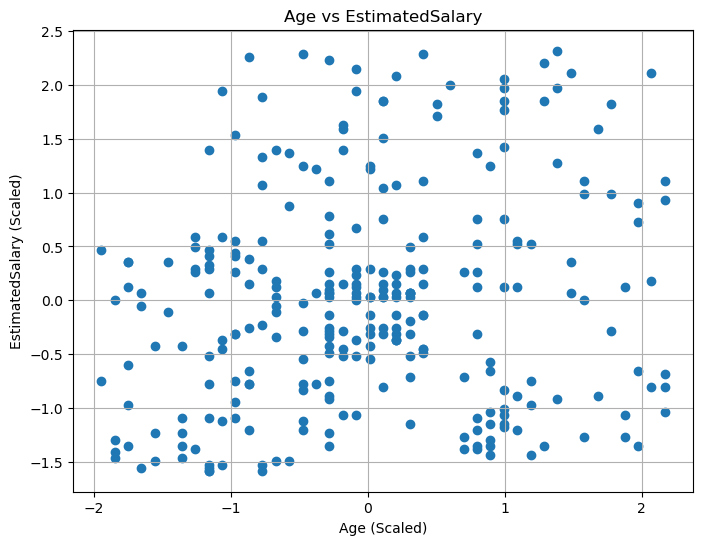

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    x_train_scaled["Age"],
    x_train_scaled["EstimatedSalary"]
)

plt.xlabel("Age (Scaled)")
plt.ylabel("EstimatedSalary (Scaled)")
plt.title("Age vs EstimatedSalary")
plt.grid(True)

plt.show()

Text(0.5, 1.0, 'After Scaling')

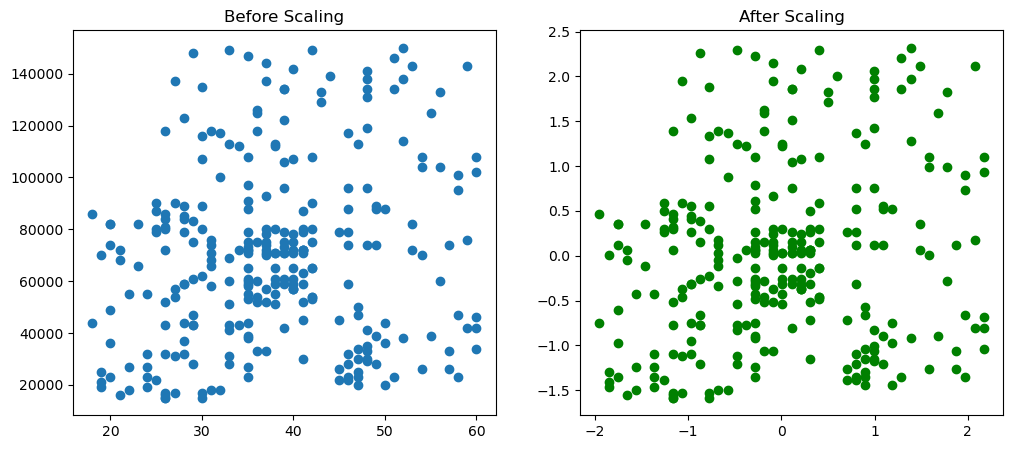

In [54]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'],label='before Scalling')
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='green')
ax1.set_title("Before Scaling")
ax2.set_title("After Scaling")

# why scalling is important

In [56]:
from sklearn.linear_model import LogisticRegression

In [58]:
lr=LogisticRegression()

In [59]:
lr_scaled=LogisticRegression()

In [62]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
y_pred=lr.predict(x_test)

In [64]:
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [67]:
from sklearn.metrics import accuracy_score

In [68]:
print('Actual',accuracy_score(y_test,y_pred));
print('Accuracy after sacling',accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Accuracy after sacling 0.8666666666666667
